# Iris Flower Classification

## Objective
Build a Machine Learning model that predicts the species of an Iris flower based on:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

Target Classes:
- Setosa
- Versicolor
- Virginica

In [19]:
# Numerical Operations
import numpy as np

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [20]:
from sklearn.datasets import load_iris

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [72]:
import os

os.makedirs("images", exist_ok=True)

print("Images folder created successfully!")

Images folder created successfully!


In [21]:
iris = load_iris()

In [22]:
print(type(iris))

<class 'sklearn.utils._bunch.Bunch'>


In [23]:
print(iris.keys())

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [24]:
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

In [25]:
df["species"] = iris.target

In [26]:
df["species"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

In [27]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [28]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (150, 5)


In [29]:
print(df.columns)

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [31]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [32]:
df.isnull().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0
species,0


In [33]:
print("Duplicate Rows:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate Rows: 1


In [34]:
print(df.shape)

(149, 5)


In [35]:
df["species"].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,49


Countplot

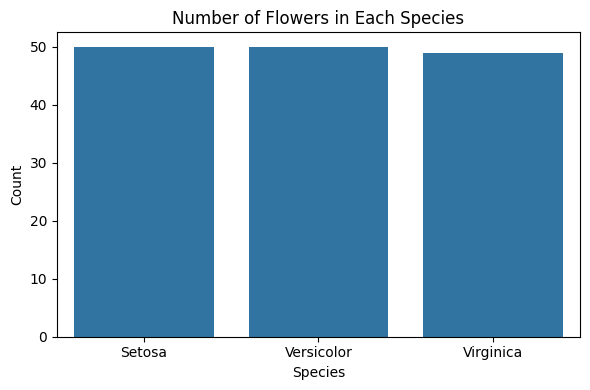

In [73]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="species",
    data=df
)

plt.title("Number of Flowers in Each Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig("images/countplot.png", dpi=300)

plt.show()

In [37]:
df.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64
species,object


In [38]:
correlation = df.drop("species", axis=1).corr()

correlation

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
sepal length (cm),1.000000,-0.118129,0.873738,0.820620
sepal width (cm),-0.118129,1.000000,-0.426028,-0.362894
petal length (cm),0.873738,-0.426028,1.000000,0.962772
petal width (cm),0.820620,-0.362894,0.962772,1.000000


Correlation heatmap

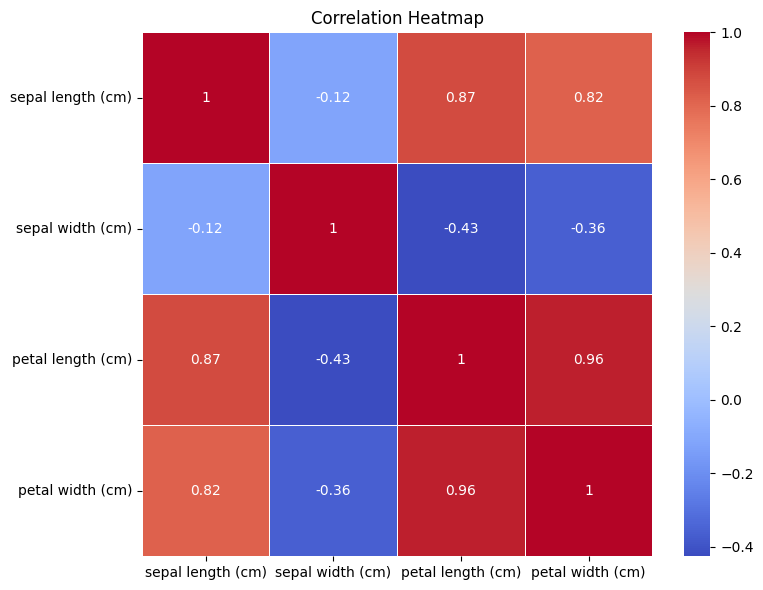

In [74]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")


plt.tight_layout()
plt.savefig("images/heatmap.png", dpi=300)
plt.show()

Histogram of all features

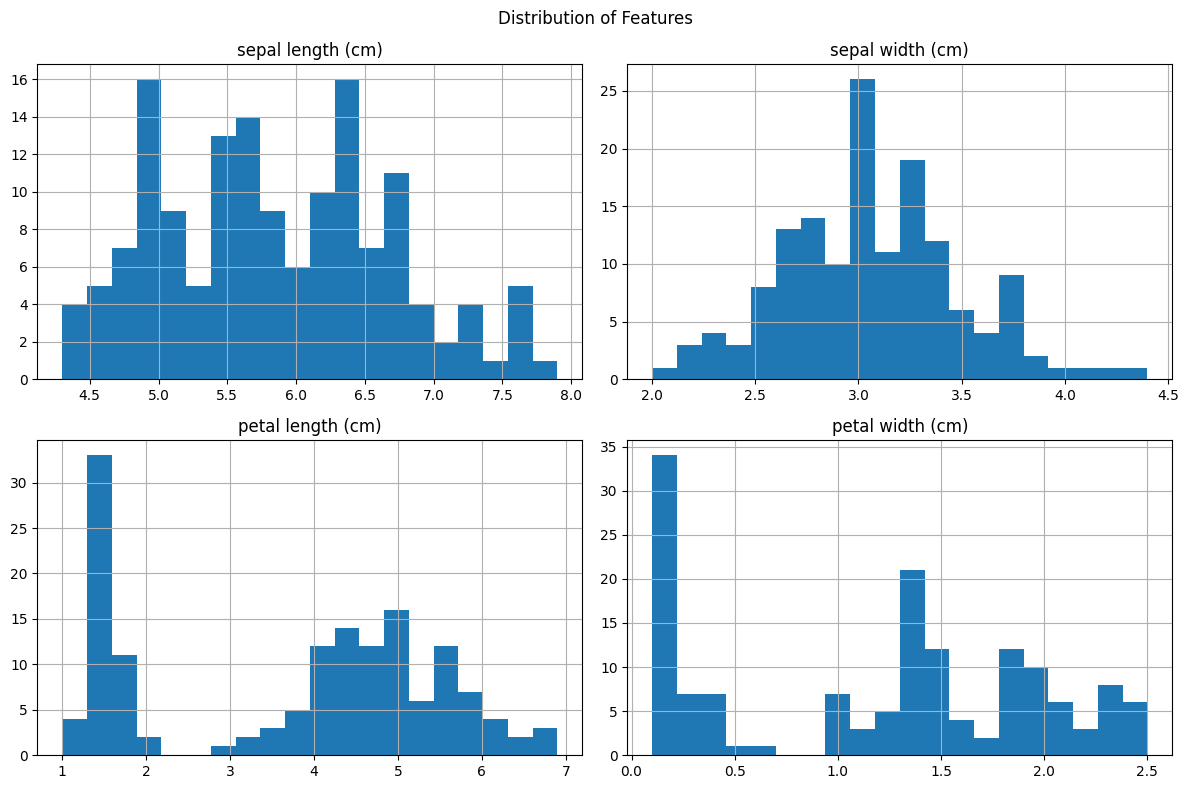

In [75]:
df.drop("species", axis=1).hist(
    figsize=(12,8),
    bins=20
)

plt.suptitle("Distribution of Features")
plt.tight_layout()
plt.savefig("images/histogram.png", dpi=300)
plt.show()

Individual histogram (petal length)

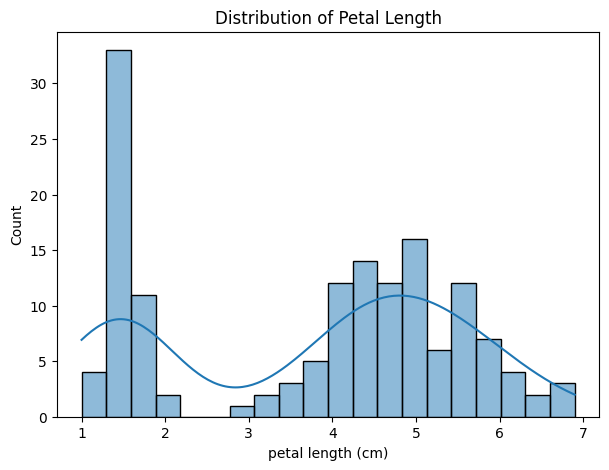

In [42]:
plt.figure(figsize=(7,5))

sns.histplot(
    data=df,
    x="petal length (cm)",
    bins=20,
    kde=True
)

plt.title("Distribution of Petal Length")
plt.show()

Box plot of all features

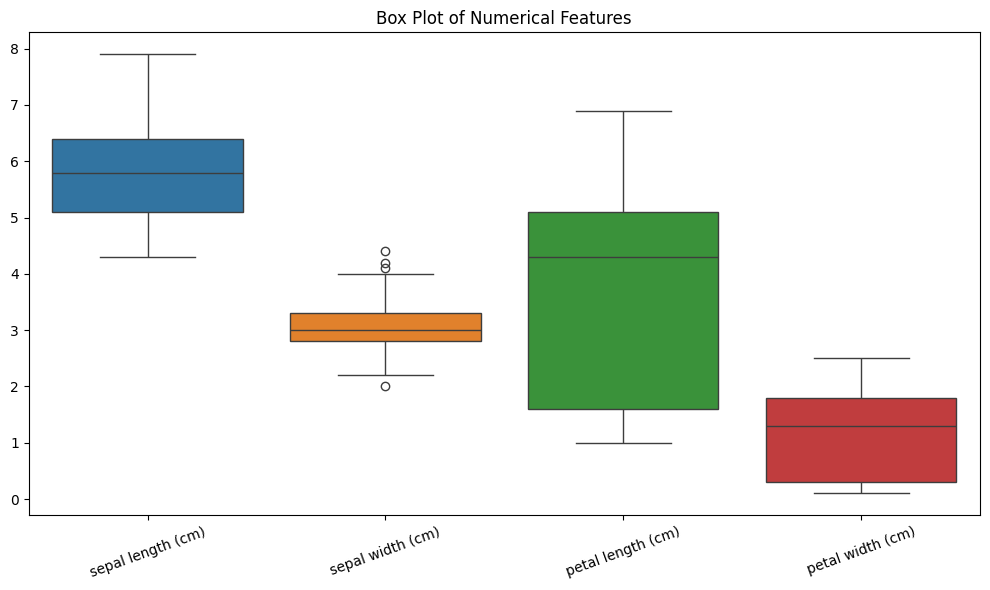

In [80]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df.drop("species", axis=1)
)

plt.title("Box Plot of Numerical Features")

plt.xticks(rotation=20)

plt.tight_layout()
plt.savefig("images/boxplot.png", dpi=300)

plt.show()

Box plot (by species)

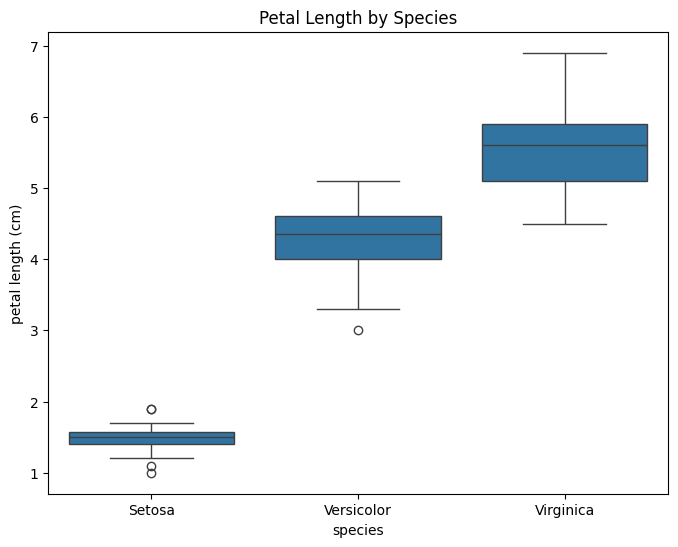

In [44]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="species",
    y="petal length (cm)",
    data=df
)

plt.title("Petal Length by Species")

plt.show()

Scatter plot

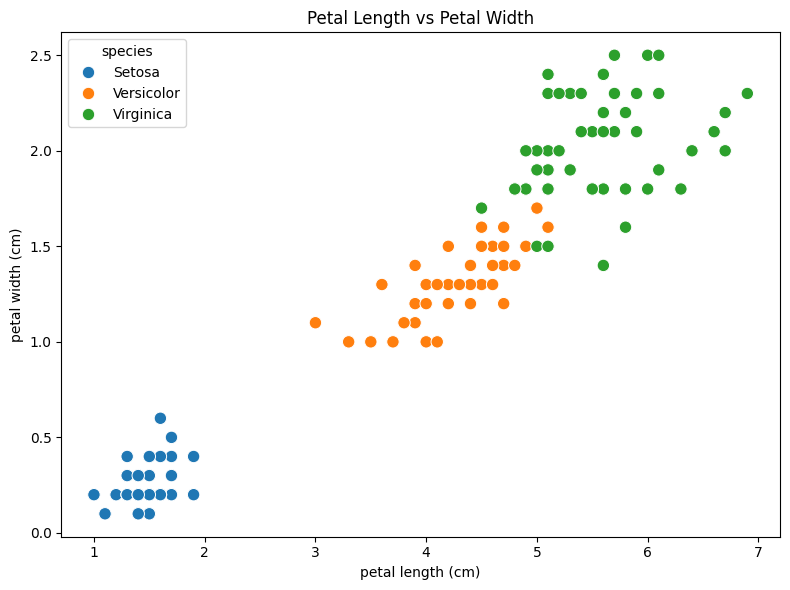

In [77]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="petal length (cm)",
    y="petal width (cm)",
    hue="species",
    s=80
)

plt.title("Petal Length vs Petal Width")

plt.tight_layout()
plt.savefig("images/scatterplot.png", dpi=300)

plt.show()

Pair plot

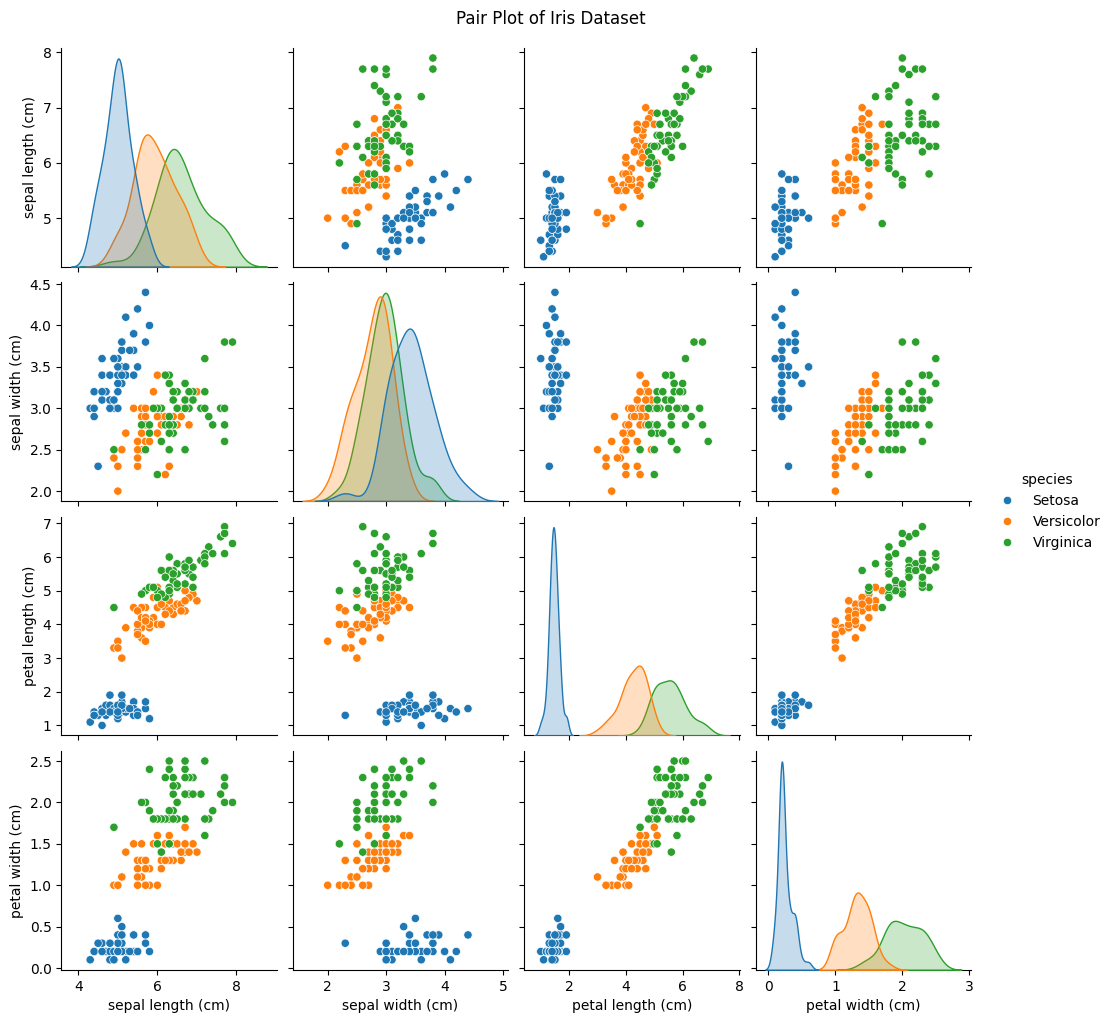

In [79]:
pair_plot = sns.pairplot(
    df,
    hue="species",
    height=2.5
)

pair_plot.fig.suptitle(
    "Pair Plot of Iris Dataset",
    y=1.02
)

pair_plot.savefig("images/pairplot.png", dpi=300)

plt.show()

Violin plot

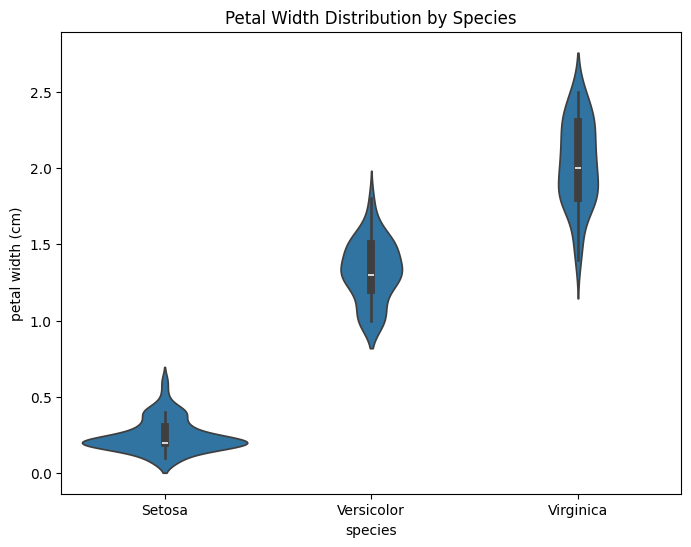

In [47]:
plt.figure(figsize=(8,6))

sns.violinplot(
    x="species",
    y="petal width (cm)",
    data=df
)

plt.title("Petal Width Distribution by Species")

plt.show()

Feature means by species

In [49]:
df.groupby("species").mean()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
species,,,,
Setosa,5.006000,3.428000,1.462000,0.246000
Versicolor,5.936000,2.770000,4.260000,1.326000
Virginica,6.604082,2.979592,5.561224,2.028571


In [50]:
print("EDA Summary")
print("-" * 40)

print("1. Dataset contains no missing values.")
print("2. Dataset is balanced.")
print("3. Petal Length and Petal Width are highly correlated.")
print("4. Setosa is easily separable.")
print("5. Versicolor and Virginica overlap slightly.")
print("6. Petal features are the most informative.")

EDA Summary
----------------------------------------
1. Dataset contains no missing values.
2. Dataset is balanced.
3. Petal Length and Petal Width are highly correlated.
4. Setosa is easily separable.
5. Versicolor and Virginica overlap slightly.
6. Petal features are the most informative.


## Separate features X and target Y

In [51]:
# Features (Input)
X = df.drop("species", axis=1)

# Target (Output)
y = df["species"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (149, 4)
Shape of y: (149,)


## Train test split

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples  :", X_test.shape[0])

Training Samples : 119
Testing Samples  : 30


DEcision tree model training

In [54]:
model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


Make predictions

In [55]:
y_pred = model.predict(X_test)

print("Actual Labels")
print(y_test.values)

print("\nPredicted Labels")
print(y_pred)

Actual Labels
['Versicolor' 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Versicolor'
 'Versicolor' 'Setosa' 'Virginica' 'Virginica' 'Setosa' 'Setosa' 'Setosa'
 'Versicolor' 'Virginica' 'Setosa' 'Versicolor' 'Setosa' 'Virginica'
 'Setosa' 'Versicolor' 'Virginica' 'Setosa' 'Setosa' 'Versicolor'
 'Versicolor' 'Virginica' 'Virginica' 'Virginica' 'Versicolor']

Predicted Labels
['Versicolor' 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Versicolor'
 'Versicolor' 'Setosa' 'Virginica' 'Virginica' 'Setosa' 'Setosa' 'Setosa'
 'Versicolor' 'Virginica' 'Setosa' 'Virginica' 'Setosa' 'Virginica'
 'Setosa' 'Versicolor' 'Versicolor' 'Setosa' 'Setosa' 'Versicolor'
 'Versicolor' 'Virginica' 'Virginica' 'Virginica' 'Versicolor']


Calculate accuracy

In [56]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy : {accuracy:.2%}")

Model Accuracy : 93.33%


Classification report

In [58]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



Confusion matrix

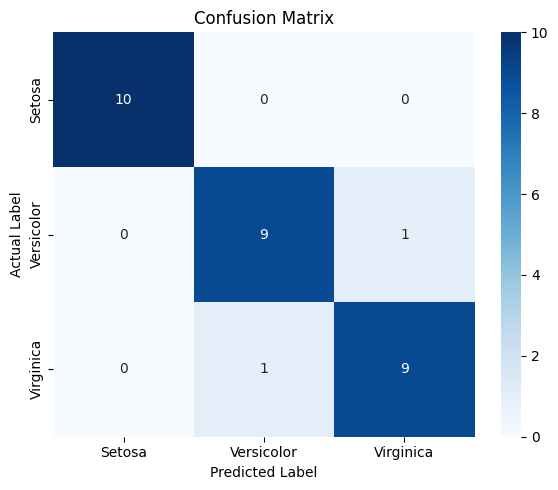

In [81]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.savefig("images/confusion_matrix.png", dpi=300)

plt.show()

Feature importance

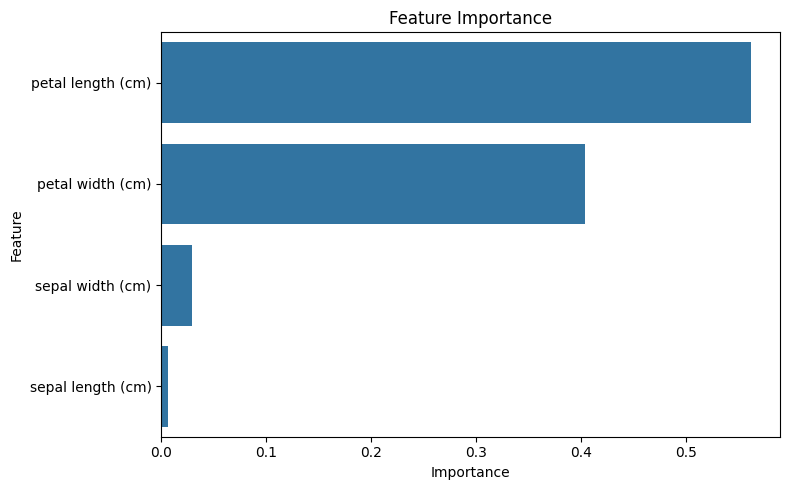

In [82]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.tight_layout()
plt.savefig("images/feature_importance.png", dpi=300)

plt.show()

# New flower prediction

In [65]:
# Sample flower measurements
# Order:
# Sepal Length
# Sepal Width
# Petal Length
# Petal Width

new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

prediction = model.predict(new_flower)

print("Predicted Species:", prediction[0])

Predicted Species: Setosa


In [66]:
flowers = np.array([
    [5.1, 3.5, 1.4, 0.2],
    [6.2, 2.9, 4.3, 1.3],
    [7.1, 3.0, 5.9, 2.1]
])

predictions = model.predict(flowers)

for i, flower in enumerate(flowers):
    print(f"Flower {i+1}")
    print("Measurements :", flower)
    print("Prediction   :", predictions[i])
    print("-" * 40)

Flower 1
Measurements : [5.1 3.5 1.4 0.2]
Prediction   : Setosa
----------------------------------------
Flower 2
Measurements : [6.2 2.9 4.3 1.3]
Prediction   : Versicolor
----------------------------------------
Flower 3
Measurements : [7.1 3.  5.9 2.1]
Prediction   : Virginica
----------------------------------------


Saving trained model

In [67]:
import pickle

with open("iris_decision_tree.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


Loading and testing of model

In [68]:
with open("iris_decision_tree.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model loaded successfully!")

Model loaded successfully!


In [69]:
sample = [[6.7, 3.1, 4.7, 1.5]]

prediction = loaded_model.predict(sample)

print("Prediction:", prediction[0])

Prediction: Versicolor


# Model performance summary

In [70]:
print("=" * 40)
print("MODEL PERFORMANCE")
print("=" * 40)

print(f"Accuracy : {accuracy:.2%}")

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

MODEL PERFORMANCE
Accuracy : 93.33%

Classification Report

              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [71]:
print("PROJECT OBSERVATIONS")
print("-" * 50)

print("1. Dataset contains no missing values.")
print("2. Dataset is balanced across all species.")
print("3. Petal features are the most informative.")
print("4. Decision Tree achieved high accuracy.")
print("5. The model successfully classifies Iris flowers.")

PROJECT OBSERVATIONS
--------------------------------------------------
1. Dataset contains no missing values.
2. Dataset is balanced across all species.
3. Petal features are the most informative.
4. Decision Tree achieved high accuracy.
5. The model successfully classifies Iris flowers.
